# CogAge Optimizer Comparison: Setup and Execution

**Tested environment:** Python 3.12.5, NumPy 2.5.3, pandas 3.0.6, Matplotlib 3.11.2, scikit-learn 1.9.1. The preprocessing script also requires joblib. Install dependencies with `python -m pip install numpy pandas matplotlib scikit-learn joblib jupyter ipykernel`.

**Data locations:** Raw recordings are expected in workspace-level `Sample/`. This notebook reads arrays from `DATA_PREP/processed_dataset/`. Do not upload the raw dataset with the assignment.

**Execution:** Open this notebook with the workspace Python environment and run cells from top to bottom. The final experiment cells run all eight optimizers and save metrics, checkpoints, plots, and a PDF report in a new timestamped `optimizer_comparison_*` folder. To intentionally regenerate preprocessing outputs, run `python DATA_PREP/prepare_dataset.py` from the workspace root first; this rewrites files in `DATA_PREP/processed_dataset/`.

**AI assistance disclosure:** GitHub Copilot assisted with drafting and debugging the preprocessing and experiment code. Review and understand the implementation, and disclose this assistance as required by course policy.

# Inspect the processed CogAge dataset

This notebook loads the prepared NumPy arrays and metadata. Each `X` row is a 128-timestep sensor window; the corresponding `y` value is its target activity ID. Training windows originate only from `_1_extracted` folders, and testing windows only from `_2_extracted` folders.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd()
candidates = [cwd / 'DATA_PREP' / 'processed_dataset', cwd / 'processed_dataset']
OUTPUT_DIR = next((path for path in candidates if path.is_dir()), None)
if OUTPUT_DIR is None:
    raise FileNotFoundError(f'Could not find processed_dataset from {cwd}')

X_train = np.load(OUTPUT_DIR / 'X_train.npy')
y_train = np.load(OUTPUT_DIR / 'y_train.npy')
X_test = np.load(OUTPUT_DIR / 'X_test.npy')
y_test = np.load(OUTPUT_DIR / 'y_test.npy')
train_metadata = pd.read_csv(OUTPUT_DIR / 'train_metadata.csv')
test_metadata = pd.read_csv(OUTPUT_DIR / 'test_metadata.csv')
feature_names = json.loads((OUTPUT_DIR / 'feature_names.json').read_text(encoding='utf-8'))
class_mapping = json.loads((OUTPUT_DIR / 'class_mapping.json').read_text(encoding='utf-8'))

print(f'Dataset folder: {OUTPUT_DIR.resolve()}')
print(f'X_train: {X_train.shape}, dtype={X_train.dtype}')
print(f'y_train: {y_train.shape}, dtype={y_train.dtype}')
print(f'X_test:  {X_test.shape}, dtype={X_test.dtype}')
print(f'y_test:  {y_test.shape}, dtype={y_test.dtype}')
print(f'Number of sensor features: {len(feature_names)}')
print(f'Class mapping: {class_mapping}')

Dataset folder: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\processed_dataset
X_train: (40, 128, 33), dtype=float32
y_train: (40,), dtype=int64
X_test:  (40, 128, 33), dtype=float32
y_test:  (40,), dtype=int64
Number of sensor features: 33
Class mapping: {'Bending': 0, 'Walking': 1, 'Sitting': 2, 'Standing': 3}


In [2]:
class_names = {label: activity for activity, label in class_mapping.items()}
distribution = pd.DataFrame({
    'activity': [class_names[label] for label in sorted(class_names)],
    'label': sorted(class_names),
    'train_windows': [int(np.sum(y_train == label)) for label in sorted(class_names)],
    'test_windows': [int(np.sum(y_test == label)) for label in sorted(class_names)],
})
display(distribution)

print('Training source folders:', sorted(train_metadata['original_folder'].unique()))
print('Testing source folders:', sorted(test_metadata['original_folder'].unique()))
print('Training metadata:')
display(train_metadata.head())
print('Testing metadata:')
display(test_metadata.head())

assert train_metadata['original_folder'].str.endswith('_1_extracted').all()
assert test_metadata['original_folder'].str.endswith('_2_extracted').all()
assert len(X_train) == len(y_train) == len(train_metadata)
assert len(X_test) == len(y_test) == len(test_metadata)
print('Split and row-alignment checks passed.')

,activity,label,train_windows,test_windows
0,Bending,0,10,10
1,Walking,1,10,10
2,Sitting,2,10,10
3,Standing,3,10,10


Training source folders: ['S1_Bending_1_extracted', 'S1_Sitting_1_extracted', 'S1_Standing_1_extracted', 'S1_Walking_1_extracted']
Testing source folders: ['S1_Bending_2_extracted', 'S1_Sitting_2_extracted', 'S1_Standing_2_extracted', 'S1_Walking_2_extracted']
Training metadata:


,subject,activity,train_or_test,activity_instance,event,window_id,label,original_folder,split
0,S1,Bending,train,1,Event_0,0,0,S1_Bending_1_extracted,train
1,S1,Bending,train,1,Event_1,0,0,S1_Bending_1_extracted,train
2,S1,Bending,train,1,Event_2,0,0,S1_Bending_1_extracted,train
3,S1,Bending,train,1,Event_3,0,0,S1_Bending_1_extracted,train
4,S1,Bending,train,1,Event_4,0,0,S1_Bending_1_extracted,train


Testing metadata:


,subject,activity,train_or_test,activity_instance,event,window_id,label,original_folder,split
0,S1,Bending,test,2,Event_0,0,0,S1_Bending_2_extracted,test
1,S1,Bending,test,2,Event_1,0,0,S1_Bending_2_extracted,test
2,S1,Bending,test,2,Event_2,0,0,S1_Bending_2_extracted,test
3,S1,Bending,test,2,Event_3,0,0,S1_Bending_2_extracted,test
4,S1,Bending,test,2,Event_4,0,0,S1_Bending_2_extracted,test


Split and row-alignment checks passed.


In [10]:
print('y_train target IDs:', y_train.tolist())

y_train_view = pd.DataFrame({
    'sample_index': np.arange(len(y_train)),
    'y_train': y_train,
    'activity': [class_names[int(label)] for label in y_train],
    'original_folder': train_metadata['original_folder'],
    'event': train_metadata['event'],
    'window_id': train_metadata['window_id'],
})
print('One row per X_train sample, with its matching target and source:')
display(y_train_view)

y_train target IDs: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
One row per X_train sample, with its matching target and source:


,sample_index,y_train,activity,original_folder,event,window_id
0,0,0,Bending,S1_Bending_1_extracted,Event_0,0
1,1,0,Bending,S1_Bending_1_extracted,Event_1,0
2,2,0,Bending,S1_Bending_1_extracted,Event_2,0
3,3,0,Bending,S1_Bending_1_extracted,Event_3,0
4,4,0,Bending,S1_Bending_1_extracted,Event_4,0
5,5,0,Bending,S1_Bending_1_extracted,Event_5,0
6,6,0,Bending,S1_Bending_1_extracted,Event_6,0
7,7,0,Bending,S1_Bending_1_extracted,Event_7,0
8,8,0,Bending,S1_Bending_1_extracted,Event_8,0
9,9,0,Bending,S1_Bending_1_extracted,Event_9,0


In [9]:
print('Sensor features:')
display(pd.DataFrame({'feature_index': range(len(feature_names)), 'feature_name': feature_names}))

# Put feature names on rows so the notebook renderer can display all 33 columns clearly.
window_preview = pd.DataFrame(
    X_train[0, :10, :].T,
    index=feature_names,
    columns=[f'timestep_{index}' for index in range(10)],
)
window_preview.index.name = 'feature_name'
print(f'Full sample shape: {X_train[0].shape} (timesteps, features)')
display(window_preview)
print('Sample target:', int(y_train[0]), '->', class_names[int(y_train[0])])
print('Sample source:', train_metadata.iloc[0][['original_folder', 'event', 'window_id']].to_dict())

Sensor features:


,feature_index,feature_name
0,0,android.sensor.accelerometer_value_1
1,1,android.sensor.accelerometer_value_2
2,2,android.sensor.accelerometer_value_3
3,3,android.sensor.gyroscope_value_1
4,4,android.sensor.gyroscope_value_2
5,5,android.sensor.gyroscope_value_3
6,6,JinsAccelerometer_value_1
7,7,JinsAccelerometer_value_2
8,8,JinsAccelerometer_value_3
9,9,JinsBlinkSpeed_value_1


Full sample shape: (128, 33) (timesteps, features)


,timestep_0,timestep_1,timestep_2,timestep_3,timestep_4,timestep_5,timestep_6,timestep_7,timestep_8,timestep_9
feature_name,,,,,,,,,,
android.sensor.accelerometer_value_1,-0.631390,-0.667417,-0.666882,-0.680259,-0.685074,-0.689354,-0.702196,-0.695775,-0.710578,-0.710221
android.sensor.accelerometer_value_2,1.134257,1.162213,1.166132,1.133211,1.122238,1.114400,1.115968,1.107345,1.104210,1.113616
android.sensor.accelerometer_value_3,-0.919039,-0.941695,-0.941695,-0.941695,-0.942375,-0.947133,-0.946453,-0.930820,-0.926742,-0.906351
android.sensor.gyroscope_value_1,0.125706,0.055797,0.048431,0.035708,0.026333,0.033699,0.033030,0.041065,0.038387,0.065841
android.sensor.gyroscope_value_2,0.102083,0.073223,0.083782,0.142440,0.188194,0.194060,0.252719,0.278529,0.306685,0.286741
android.sensor.gyroscope_value_3,0.173660,0.214578,0.228402,0.230061,0.210155,0.181401,0.150988,0.132188,0.112834,0.096245
JinsAccelerometer_value_1,-1.666967,-1.666967,-1.666967,-1.666967,-1.666967,-1.666967,-1.666967,-1.666967,-1.666967,-1.666967
JinsAccelerometer_value_2,1.533632,1.533632,1.533632,1.533632,1.533632,1.533632,1.533632,1.533632,1.533632,1.533632
JinsAccelerometer_value_3,1.768613,1.768613,1.768613,1.768613,1.768613,1.768613,1.768613,1.768613,1.768613,1.768613


Sample target: 0 -> Bending
Sample source: {'original_folder': 'S1_Bending_1_extracted', 'event': 'Event_0', 'window_id': 0}


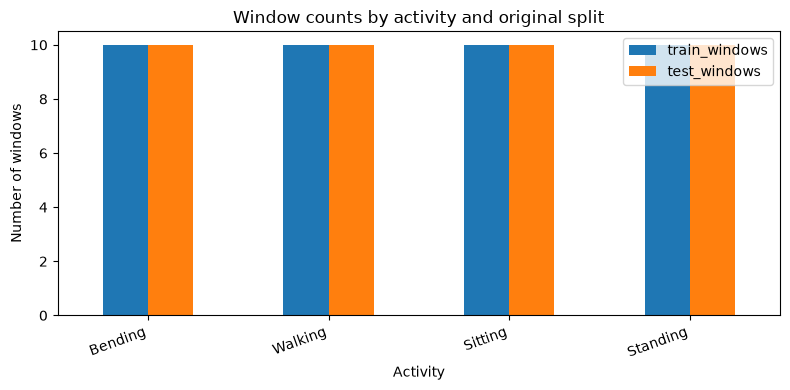

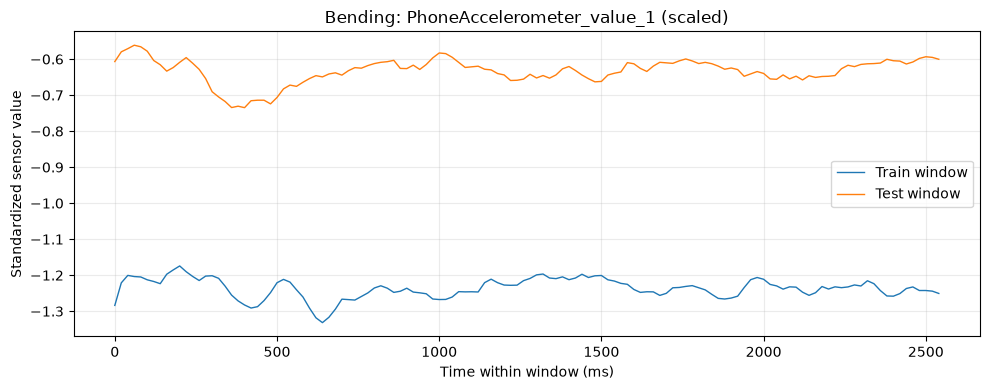

Train example source: S1_Bending_1_extracted Event_0
Test example source:  S1_Bending_2_extracted Event_0


In [8]:
# Plot class counts and one same-class sensor feature from train and test.
distribution.plot(x='activity', y=['train_windows', 'test_windows'], kind='bar', figsize=(8, 4))
plt.title('Window counts by activity and original split')
plt.ylabel('Number of windows')
plt.xlabel('Activity')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

activity_to_plot = next(iter(class_mapping))
label_to_plot = class_mapping[activity_to_plot]
train_index = int(np.flatnonzero(y_train == label_to_plot)[0])
test_index = int(np.flatnonzero(y_test == label_to_plot)[0])
feature_index = next((i for i, name in enumerate(feature_names) if 'PhoneAccelerometer' in name), 0)
time_ms = np.arange(X_train.shape[1]) * 20
plt.figure(figsize=(10, 4))
plt.plot(time_ms, X_train[train_index, :, feature_index], label='Train window', linewidth=1)
plt.plot(time_ms, X_test[test_index, :, feature_index], label='Test window', linewidth=1)
plt.title(f'{activity_to_plot}: {feature_names[feature_index]} (scaled)')
plt.xlabel('Time within window (ms)')
plt.ylabel('Standardized sensor value')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Train example source:', train_metadata.iloc[train_index]['original_folder'], train_metadata.iloc[train_index]['event'])
print('Test example source: ', test_metadata.iloc[test_index]['original_folder'], test_metadata.iloc[test_index]['event'])

In [9]:
X_train

array([[[-0.6313904 ,  1.1342566 , -0.9190386 , ...,  0.5404262 ,
         -0.78720784, -0.5872892 ],
        [-0.66741717,  1.1622127 , -0.9416951 , ...,  0.5421546 ,
         -0.7939085 , -0.5782097 ],
        [-0.6668821 ,  1.1661319 , -0.9416951 , ...,  0.54790825,
         -0.7939085 , -0.5887854 ],
        ...,
        [-0.56629246,  1.2155123 , -0.94441384, ...,  0.56230986,
         -0.72873026, -0.6703681 ],
        [-0.58073896,  1.2304049 , -0.95800775, ...,  0.5830452 ,
         -0.70862204, -0.65274185],
        [-0.6165874 ,  1.2217829 , -0.9620859 , ...,  0.58880466,
         -0.71531653, -0.649729  ]],

       [[-0.4838948 ,  0.01000108, -0.01799073, ...,  0.71434134,
         -0.52152365, -0.93634427],
        [-0.44644123,  0.0076496 ,  0.03910351, ...,  0.7247119 ,
         -0.5294393 , -0.9151877 ],
        [-0.4405556 , -0.00332383,  0.15737027, ...,  0.72356355,
         -0.5178727 , -0.9172014 ],
        ...,
        [-0.5866244 ,  0.6723268 , -1.128611  , ...,  

In [3]:
# X_train contains 40 windows; display one complete window rather than dumping the entire tensor.
sample_index = 0
sample_label = int(y_train[sample_index])
sample_metadata = train_metadata.iloc[sample_index]
sample_window = pd.DataFrame(X_train[sample_index], columns=feature_names)
sample_window.index.name = 'timestep (20 ms each)'

print(f'X_train shape: {X_train.shape} (windows, timesteps, features)')
print(f'Showing X_train[{sample_index}]: {sample_window.shape} (timesteps, features)')
print(f'Target: {sample_label} -> {class_names[sample_label]}')
print(f"Source: {sample_metadata['original_folder']} / {sample_metadata['event']}")

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(sample_window)

X_train shape: (40, 128, 33) (windows, timesteps, features)
Showing X_train[0]: (128, 33) (timesteps, features)
Target: 0 -> Bending
Source: S1_Bending_1_extracted / Event_0


,android.sensor.accelerometer_value_1,android.sensor.accelerometer_value_2,android.sensor.accelerometer_value_3,android.sensor.gyroscope_value_1,android.sensor.gyroscope_value_2,android.sensor.gyroscope_value_3,JinsAccelerometer_value_1,JinsAccelerometer_value_2,JinsAccelerometer_value_3,JinsBlinkSpeed_value_1,JinsBlinkStrength_value_1,JinsEyeMovement_value_1,JinsEyeMovement_value_2,JinsEyeMovement_value_3,JinsEyeMovement_value_4,JinsGyroscope_value_1,JinsGyroscope_value_2,JinsGyroscope_value_3,PhoneAccelerometer_value_1,PhoneAccelerometer_value_2,PhoneAccelerometer_value_3,PhoneGravity_value_1,PhoneGravity_value_2,PhoneGravity_value_3,PhoneGyroscope_value_1,PhoneGyroscope_value_2,PhoneGyroscope_value_3,PhoneLinearAccelerometer_value_1,PhoneLinearAccelerometer_value_2,PhoneLinearAccelerometer_value_3,PhoneMagnetometer_value_1,PhoneMagnetometer_value_2,PhoneMagnetometer_value_3
timestep (20 ms each),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.631390,1.134257,-0.919039,0.125706,0.102083,0.173660,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.450899,1.804394,0.671186,-1.283849,0.384061,0.158010,-1.620544,0.405685,0.172482,-0.032661,-0.014064,0.058691,0.074925,-0.011415,-0.012262,0.540426,-0.787208,-0.587289
1,-0.667417,1.162213,-0.941695,0.055797,0.073223,0.214578,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.450899,1.796402,0.671371,-1.221188,0.361960,0.166146,-1.617759,0.406383,0.173279,-0.064213,-0.006845,0.078446,0.178247,-0.064224,0.004399,0.542155,-0.793908,-0.578210
2,-0.666882,1.166132,-0.941695,0.048431,0.083782,0.228402,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.450299,1.792269,0.671588,-1.200497,0.365459,0.171616,-1.612930,0.407687,0.175003,-0.091108,-0.001694,0.061989,0.205572,-0.056496,0.011915,0.547908,-0.793908,-0.588785
3,-0.680259,1.133211,-0.941695,0.035708,0.142440,0.230061,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.449699,1.788135,0.671804,-1.203703,0.378886,0.174703,-1.608272,0.409211,0.177623,-0.087154,-0.010972,-0.000529,0.193282,-0.025640,0.012760,0.555964,-0.792700,-0.573665
4,-0.685074,1.122238,-0.942375,0.026333,0.188194,0.210155,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.449099,1.784001,0.672021,-1.204868,0.395251,0.160815,-1.604967,0.410476,0.180145,-0.073175,-0.009598,-0.026833,0.186347,0.011631,-0.025644,0.565755,-0.789036,-0.560568
5,-0.689354,1.114400,-0.947133,0.033699,0.194060,0.181401,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.450899,1.781981,0.672361,-1.212739,0.391054,0.178488,-1.602179,0.411473,0.182036,-0.070304,-0.007190,-0.059732,0.169145,0.000177,0.012451,0.560576,-0.797566,-0.548988
6,-0.702196,1.115968,-0.946453,0.033030,0.252719,0.150988,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.452699,1.779960,0.672701,-1.217401,0.393152,0.169653,-1.600669,0.412307,0.184115,-0.058836,-0.000665,-0.068479,0.158694,0.004263,-0.012912,0.559427,-0.792681,-0.545463
7,-0.695775,1.107345,-0.930820,0.041065,0.278529,0.132188,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.454499,1.777939,0.673041,-1.223521,0.400147,0.164743,-1.599160,0.412910,0.185375,-0.050229,-0.003413,-0.080556,0.146056,0.019733,-0.027037,0.547340,-0.795117,-0.562085
8,-0.710578,1.104210,-0.926742,0.038387,0.306685,0.112834,-1.666967,1.533632,1.768613,-0.155619,-0.149048,-0.231280,-0.080370,-0.115199,-0.099206,-0.459000,1.776561,0.673459,-1.197290,0.400287,0.154082,-1.598063,0.413332,0.186232,-0.036974,-0.020944,-0.098081,0.190590,0.019026,-0.053979,0.538118,-0.796345,-0.571656


In [10]:
y_train

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [11]:
# Build model train/validation sets from the original training recordings only.
# Group by source folder + Event so windows from one Event cannot cross this split.
from sklearn.preprocessing import StandardScaler

VALIDATION_FRACTION = 0.20
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
event_groups = (
    train_metadata['original_folder'].astype(str) + '::' + train_metadata['event'].astype(str)
).to_numpy()

model_train_indices = []
validation_indices = []
for class_id in sorted(np.unique(y_train)):
    class_indices = np.flatnonzero(y_train == class_id)
    class_groups = np.unique(event_groups[class_indices])
    if len(class_groups) < 2:
        raise ValueError(f'Class {class_id} needs at least two Events for a grouped validation split.')

    validation_group_count = max(1, int(round(len(class_groups) * VALIDATION_FRACTION)))
    validation_group_count = min(validation_group_count, len(class_groups) - 1)
    selected_validation_groups = rng.choice(
        class_groups, size=validation_group_count, replace=False
    )
    is_validation = np.isin(event_groups[class_indices], selected_validation_groups)
    validation_indices.extend(class_indices[is_validation].tolist())
    model_train_indices.extend(class_indices[~is_validation].tolist())

model_train_indices = np.array(sorted(model_train_indices), dtype=int)
validation_indices = np.array(sorted(validation_indices), dtype=int)

# Refit scaling after the split; this scaler sees only the model-training windows.
# Re-standardizing these already scaled arrays is equivalent to fitting on the underlying
# raw values because the earlier per-feature StandardScaler transform is affine.
model_scaler = StandardScaler()
model_scaler.fit(X_train[model_train_indices].reshape(-1, X_train.shape[-1]))

def apply_model_scaler(windows):
    flat = windows.reshape(-1, windows.shape[-1])
    scaled = model_scaler.transform(flat)
    return scaled.reshape(windows.shape).astype(np.float32)

X_model_train = apply_model_scaler(X_train[model_train_indices])
y_model_train = y_train[model_train_indices].copy()
metadata_model_train = train_metadata.iloc[model_train_indices].reset_index(drop=True)

X_validation = apply_model_scaler(X_train[validation_indices])
y_validation = y_train[validation_indices].copy()
metadata_validation = train_metadata.iloc[validation_indices].reset_index(drop=True)

# Keep original test samples held out; only transform them with the training-fitted scaler.
X_test_model = apply_model_scaler(X_test)
y_test_model = y_test.copy()

train_groups = set(event_groups[model_train_indices])
validation_groups = set(event_groups[validation_indices])
assert train_groups.isdisjoint(validation_groups)
assert metadata_model_train['original_folder'].str.endswith('_1_extracted').all()
assert metadata_validation['original_folder'].str.endswith('_1_extracted').all()
assert test_metadata['original_folder'].str.endswith('_2_extracted').all()
assert len(X_model_train) == len(y_model_train) == len(metadata_model_train)
assert len(X_validation) == len(y_validation) == len(metadata_validation)
assert len(X_test_model) == len(y_test_model) == len(test_metadata)

split_counts = pd.DataFrame({
    'activity': [class_names[int(class_id)] for class_id in sorted(class_mapping.values())],
    'label': sorted(class_mapping.values()),
    'model_train': [int(np.sum(y_model_train == class_id)) for class_id in sorted(class_mapping.values())],
    'validation': [int(np.sum(y_validation == class_id)) for class_id in sorted(class_mapping.values())],
    'held_out_test': [int(np.sum(y_test_model == class_id)) for class_id in sorted(class_mapping.values())],
})
print(f'Random seed: {RANDOM_SEED}; validation fraction per class: {VALIDATION_FRACTION:.0%} of Event groups')
print(f'Model train: {X_model_train.shape}; validation: {X_validation.shape}; held-out test: {X_test_model.shape}')
print('No Event group is shared between model train and validation.')
print('Limitation: all selected recordings are Subject 1, so these splits are not participant-independent.')
display(split_counts)

Random seed: 42; validation fraction per class: 20% of Event groups
Model train: (32, 128, 33); validation: (8, 128, 33); held-out test: (40, 128, 33)
No Event group is shared between model train and validation.
Limitation: all selected recordings are Subject 1, so these splits are not participant-independent.


,activity,label,model_train,validation,held_out_test
0,Bending,0,8,2,10
1,Walking,1,8,2,10
2,Sitting,2,8,2,10
3,Standing,3,8,2,10


## Optimizer comparison

This section flattens each 128 x 33 window into 4,224 inputs for a fully connected network with two ReLU hidden layers and four output logits. All eight runs use the same architecture, initialization seed, data splits, maximum epochs, and base learning rate. Validation comes only from original `_1_extracted` Events; the `_2_extracted` test set is evaluated once per run after selecting the checkpoint with the lowest validation loss. The model-training set is small (32 windows), so report that limitation when interpreting results.

In [5]:
import copy
import json
import time
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

EXPERIMENT_SEED = 42
MAX_EPOCHS = 100
MINI_BATCH_SIZE = 8
BASE_LEARNING_RATE = 0.01
MOMENTUM_COEFFICIENT = 0.9
ADAMW_WEIGHT_DECAY = 0.01
HIDDEN_DIMS = (32, 16)
CLASS_IDS = np.array(sorted(class_mapping.values()), dtype=np.int64)

# Use a fresh timestamped directory so this experiment cannot overwrite prior outputs.
from datetime import datetime
EXPERIMENT_DIR = OUTPUT_DIR / f"optimizer_comparison_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
MODEL_DIR = EXPERIMENT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=False)

X_fit = X_model_train.reshape(len(X_model_train), -1).astype(np.float64)
X_valid = X_validation.reshape(len(X_validation), -1).astype(np.float64)
X_heldout = X_test_model.reshape(len(X_test_model), -1).astype(np.float64)
Y_fit = y_model_train.astype(np.int64)
Y_valid = y_validation.astype(np.int64)
Y_heldout = y_test_model.astype(np.int64)
INPUT_DIM = X_fit.shape[1]


def initialize_mlp(seed):
    rng = np.random.default_rng(seed)
    dims = (INPUT_DIM, *HIDDEN_DIMS, len(CLASS_IDS))
    params = {}
    for layer in range(1, len(dims)):
        fan_in, fan_out = dims[layer - 1], dims[layer]
        params[f'W{layer}'] = rng.normal(0, np.sqrt(2.0 / fan_in), (fan_in, fan_out))
        params[f'b{layer}'] = np.zeros(fan_out, dtype=np.float64)
    return params


def mlp_forward(features, params):
    z1 = features @ params['W1'] + params['b1']
    h1 = np.maximum(z1, 0)
    z2 = h1 @ params['W2'] + params['b2']
    h2 = np.maximum(z2, 0)
    logits = h2 @ params['W3'] + params['b3']
    return logits, (features, z1, h1, z2, h2)


def probabilities_from_logits(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def loss_and_accuracy(features, labels, params):
    logits, _ = mlp_forward(features, params)
    probs = probabilities_from_logits(logits)
    row_ids = np.arange(len(labels))
    loss = -np.log(np.clip(probs[row_ids, labels], 1e-12, 1.0)).mean()
    accuracy = np.mean(np.argmax(logits, axis=1) == labels)
    return float(loss), float(accuracy)


def batch_gradients(features, labels, params):
    logits, cache = mlp_forward(features, params)
    batch_features, z1, h1, z2, h2 = cache
    probs = probabilities_from_logits(logits)
    row_ids = np.arange(len(labels))
    loss = -np.log(np.clip(probs[row_ids, labels], 1e-12, 1.0)).mean()

    dlogits = probs
    dlogits[row_ids, labels] -= 1.0
    dlogits /= len(labels)
    gradients = {}
    gradients['W3'] = h2.T @ dlogits
    gradients['b3'] = dlogits.sum(axis=0)
    dh2 = dlogits @ params['W3'].T
    dz2 = dh2 * (z2 > 0)
    gradients['W2'] = h1.T @ dz2
    gradients['b2'] = dz2.sum(axis=0)
    dh1 = dz2 @ params['W2'].T
    dz1 = dh1 * (z1 > 0)
    gradients['W1'] = batch_features.T @ dz1
    gradients['b1'] = dz1.sum(axis=0)
    return float(loss), gradients


def initialize_optimizer_state(optimizer_name, params):
    zeros = {name: np.zeros_like(value) for name, value in params.items()}
    if optimizer_name == 'momentum':
        return {'velocity': zeros}
    if optimizer_name == 'adagrad':
        return {'sum_squares': zeros}
    if optimizer_name == 'rmsprop':
        return {'average_squares': zeros}
    if optimizer_name in ('adam', 'adamw'):
        return {'first_moment': copy.deepcopy(zeros), 'second_moment': copy.deepcopy(zeros)}
    return {}


def apply_optimizer_update(params, gradients, state, optimizer_name, step):
    epsilon = 1e-8
    for name in params:
        gradient = gradients[name]
        if optimizer_name in ('full_batch_gd', 'mini_batch_gd', 'sgd'):
            params[name] -= BASE_LEARNING_RATE * gradient
        elif optimizer_name == 'momentum':
            state['velocity'][name] = MOMENTUM_COEFFICIENT * state['velocity'][name] + gradient
            params[name] -= BASE_LEARNING_RATE * state['velocity'][name]
        elif optimizer_name == 'adagrad':
            state['sum_squares'][name] += gradient * gradient
            params[name] -= BASE_LEARNING_RATE * gradient / (np.sqrt(state['sum_squares'][name]) + epsilon)
        elif optimizer_name == 'rmsprop':
            alpha = 0.99
            state['average_squares'][name] = (
                alpha * state['average_squares'][name] + (1 - alpha) * gradient * gradient
            )
            params[name] -= BASE_LEARNING_RATE * gradient / (np.sqrt(state['average_squares'][name]) + epsilon)
        elif optimizer_name in ('adam', 'adamw'):
            beta1, beta2 = 0.9, 0.999
            first = state['first_moment'][name]
            second = state['second_moment'][name]
            first *= beta1
            first += (1 - beta1) * gradient
            second *= beta2
            second += (1 - beta2) * gradient * gradient
            corrected_first = first / (1 - beta1 ** step)
            corrected_second = second / (1 - beta2 ** step)
            if optimizer_name == 'adamw':
                params[name] *= 1 - BASE_LEARNING_RATE * ADAMW_WEIGHT_DECAY
            params[name] -= BASE_LEARNING_RATE * corrected_first / (np.sqrt(corrected_second) + epsilon)
        else:
            raise ValueError(f'Unknown optimizer: {optimizer_name}')


OPTIMIZER_CONFIGS = [
    {'name': 'Full-batch GD', 'key': 'full_batch_gd', 'batch_size': None},
    {'name': 'Mini-batch GD', 'key': 'mini_batch_gd', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'Stochastic GD', 'key': 'sgd', 'batch_size': 1},
    {'name': 'SGD + Momentum', 'key': 'momentum', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'Adagrad', 'key': 'adagrad', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'RMSprop', 'key': 'rmsprop', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'Adam', 'key': 'adam', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'AdamW', 'key': 'adamw', 'batch_size': MINI_BATCH_SIZE},
]

# The fixed architecture has two ReLU hidden layers and four unnormalized class logits.
PARAMETER_COUNT = sum(
    (left + 1) * right
    for left, right in zip((INPUT_DIM, *HIDDEN_DIMS), (*HIDDEN_DIMS, len(CLASS_IDS)))
)
print(f'Architecture: {INPUT_DIM} -> {HIDDEN_DIMS[0]} -> {HIDDEN_DIMS[1]} -> {len(CLASS_IDS)} logits')
print(f'Trainable parameters: {PARAMETER_COUNT:,}')
print(f'Base LR={BASE_LEARNING_RATE}; mini-batch={MINI_BATCH_SIZE}; momentum={MOMENTUM_COEFFICIENT}; epochs={MAX_EPOCHS}')
print('Plain NumPy implementation; cross-entropy is computed directly from logits via stable softmax.')

experiment_histories = {}
experiment_metrics = []
experiment_confusion = {}
best_parameters = {}

for config in OPTIMIZER_CONFIGS:
    optimizer_name = config['name']
    optimizer_key = config['key']
    batch_size = config['batch_size']
    params = initialize_mlp(EXPERIMENT_SEED)
    optimizer_state = initialize_optimizer_state(optimizer_key, params)
    batch_rng = np.random.default_rng(EXPERIMENT_SEED + 1)
    updates_per_epoch = 1 if batch_size is None else int(np.ceil(len(X_fit) / batch_size))
    update_count = 0
    best_validation_loss = np.inf
    best_epoch = 0
    best_checkpoint = copy.deepcopy(params)
    rows = []
    run_started = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_started = time.perf_counter()
        if batch_size is None:
            batches = [np.arange(len(X_fit))]
        else:
            order = batch_rng.permutation(len(X_fit))
            batches = [order[start:start + batch_size] for start in range(0, len(order), batch_size)]

        for batch_indices in batches:
            _, gradients = batch_gradients(X_fit[batch_indices], Y_fit[batch_indices], params)
            update_count += 1
            apply_optimizer_update(params, gradients, optimizer_state, optimizer_key, update_count)

        train_loss, train_accuracy = loss_and_accuracy(X_fit, Y_fit, params)
        validation_loss, validation_accuracy = loss_and_accuracy(X_valid, Y_valid, params)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_checkpoint = copy.deepcopy(params)
        rows.append({
            'optimizer': optimizer_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'validation_loss': validation_loss,
            'train_accuracy': train_accuracy,
            'validation_accuracy': validation_accuracy,
            'updates_this_epoch': updates_per_epoch,
            'cumulative_updates': update_count,
            'elapsed_seconds': time.perf_counter() - run_started,
            'epoch_seconds': time.perf_counter() - epoch_started,
        })

    training_seconds = time.perf_counter() - run_started
    # Evaluate the held-out test set only once, using the selected validation checkpoint.
    test_loss, test_accuracy = loss_and_accuracy(X_heldout, Y_heldout, best_checkpoint)
    test_logits, _ = mlp_forward(X_heldout, best_checkpoint)
    test_predictions = np.argmax(test_logits, axis=1)
    test_macro_f1 = f1_score(Y_heldout, test_predictions, labels=CLASS_IDS, average='macro', zero_division=0)
    test_confusion = confusion_matrix(Y_heldout, test_predictions, labels=CLASS_IDS)

    experiment_histories[optimizer_name] = pd.DataFrame(rows)
    experiment_confusion[optimizer_name] = test_confusion
    best_parameters[optimizer_name] = best_checkpoint
    experiment_metrics.append({
        'optimizer': optimizer_name,
        'best_validation_loss': best_validation_loss,
        'best_epoch': best_epoch,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_macro_f1': float(test_macro_f1),
        'training_seconds': training_seconds,
        'updates_per_epoch': updates_per_epoch,
        'total_updates': update_count,
        'checkpoint_epoch': best_epoch,
    })
    np.savez_compressed(MODEL_DIR / f'{optimizer_key}_best.npz', **best_checkpoint)
    print(
        f'{optimizer_name}: best val loss={best_validation_loss:.4f} at epoch {best_epoch}; '
        f'test accuracy={test_accuracy:.3f}, macro F1={test_macro_f1:.3f}; '
        f'{update_count:,} updates in {training_seconds:.2f}s'
    )

experiment_results = pd.DataFrame(experiment_metrics)
experiment_history_table = pd.concat(experiment_histories.values(), ignore_index=True)
experiment_results.to_csv(EXPERIMENT_DIR / 'optimizer_summary.csv', index=False)
experiment_history_table.to_csv(EXPERIMENT_DIR / 'training_history.csv', index=False)
with (EXPERIMENT_DIR / 'confusion_matrices.json').open('w', encoding='utf-8') as output_file:
    json.dump({name: matrix.tolist() for name, matrix in experiment_confusion.items()}, output_file, indent=2)
with (EXPERIMENT_DIR / 'experiment_config.json').open('w', encoding='utf-8') as output_file:
    json.dump({
        'seed': EXPERIMENT_SEED,
        'epochs': MAX_EPOCHS,
        'base_learning_rate': BASE_LEARNING_RATE,
        'mini_batch_size': MINI_BATCH_SIZE,
        'momentum': MOMENTUM_COEFFICIENT,
        'adamw_weight_decay': ADAMW_WEIGHT_DECAY,
        'hidden_dims': HIDDEN_DIMS,
        'input_dim': INPUT_DIM,
        'output_classes': len(CLASS_IDS),
        'parameter_count': PARAMETER_COUNT,
        'train_windows': len(X_fit),
        'validation_windows': len(X_valid),
        'test_windows': len(X_heldout),
        'validation_policy': '20% of Event groups per class from original _1_extracted folders',
        'scaling': 'model_scaler fit on model-training windows only; applied to validation and test',
    }, output_file, indent=2)

display(experiment_results.sort_values('best_validation_loss').reset_index(drop=True))
print(f'New experiment outputs: {EXPERIMENT_DIR.resolve()}')

Architecture: 4224 -> 32 -> 16 -> 4 logits
Trainable parameters: 135,796
Base LR=0.01; mini-batch=8; momentum=0.9; epochs=100
Plain NumPy implementation; cross-entropy is computed directly from logits via stable softmax.
Full-batch GD: best val loss=0.1720 at epoch 100; test accuracy=0.725, macro F1=0.662; 100 updates in 0.54s
Mini-batch GD: best val loss=0.2271 at epoch 100; test accuracy=0.800, macro F1=0.785; 400 updates in 0.88s
Stochastic GD: best val loss=0.0037 at epoch 1; test accuracy=0.900, macro F1=0.902; 3,200 updates in 4.91s
SGD + Momentum: best val loss=0.0054 at epoch 6; test accuracy=0.800, macro F1=0.807; 400 updates in 1.46s
Adagrad: best val loss=0.0881 at epoch 2; test accuracy=0.875, macro F1=0.871; 400 updates in 2.10s
RMSprop: best val loss=3.4539 at epoch 3; test accuracy=0.950, macro F1=0.949; 400 updates in 2.34s
Adam: best val loss=0.1039 at epoch 10; test accuracy=0.925, macro F1=0.923; 400 updates in 2.77s
AdamW: best val loss=0.1066 at epoch 10; test accu

,optimizer,best_validation_loss,best_epoch,test_loss,test_accuracy,test_macro_f1,training_seconds,updates_per_epoch,total_updates,checkpoint_epoch
0,Stochastic GD,0.003745,1,0.244142,0.900,0.901768,4.905491,32,3200,1
1,SGD + Momentum,0.005422,6,1.377461,0.800,0.806760,1.463585,4,400,6
2,Adagrad,0.088139,2,0.377785,0.875,0.871250,2.102147,4,400,2
3,Adam,0.103892,10,1.402112,0.925,0.923413,2.773657,4,400,10
4,AdamW,0.106570,10,1.402638,0.925,0.923413,2.937906,4,400,10
5,Full-batch GD,0.172028,100,0.832300,0.725,0.662458,0.538621,1,100,100
6,Mini-batch GD,0.227097,100,0.430582,0.800,0.785119,0.881268,4,400,100
7,RMSprop,3.453878,3,0.953780,0.950,0.949495,2.337891,4,400,3


New experiment outputs: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\processed_dataset\optimizer_comparison_20261003_095659


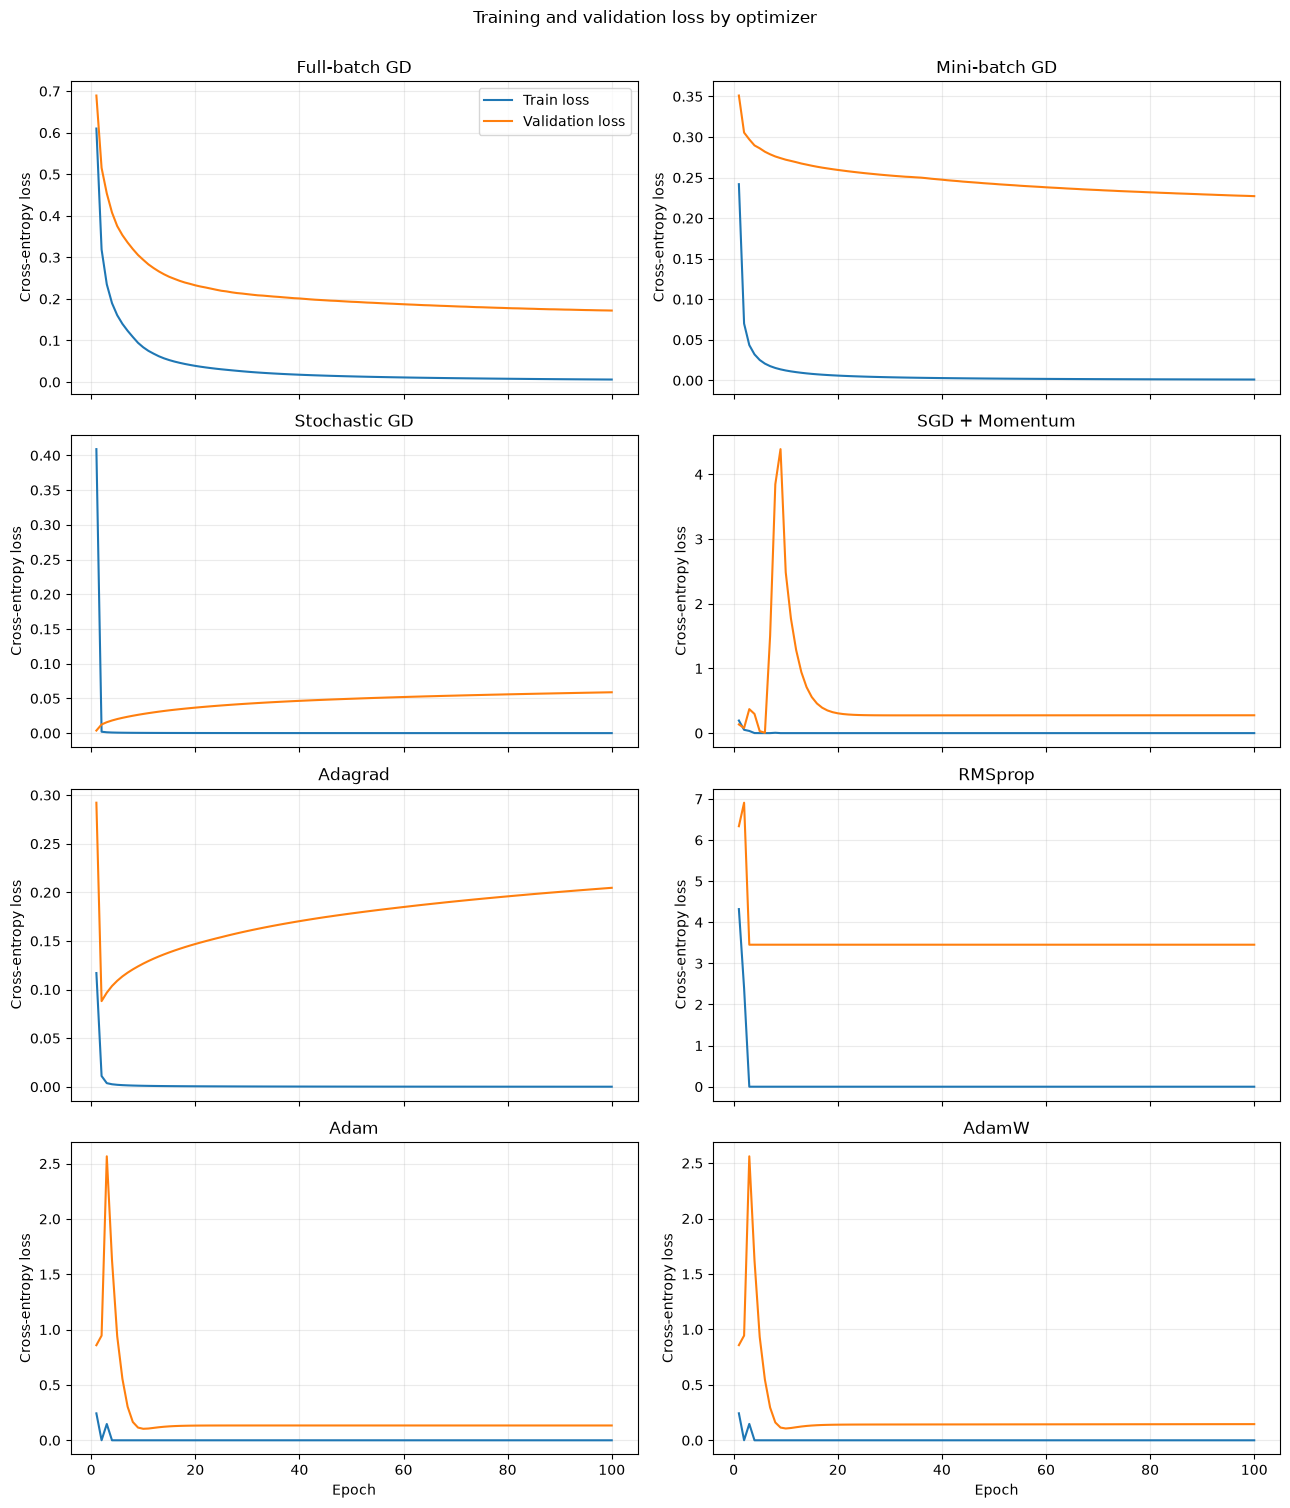

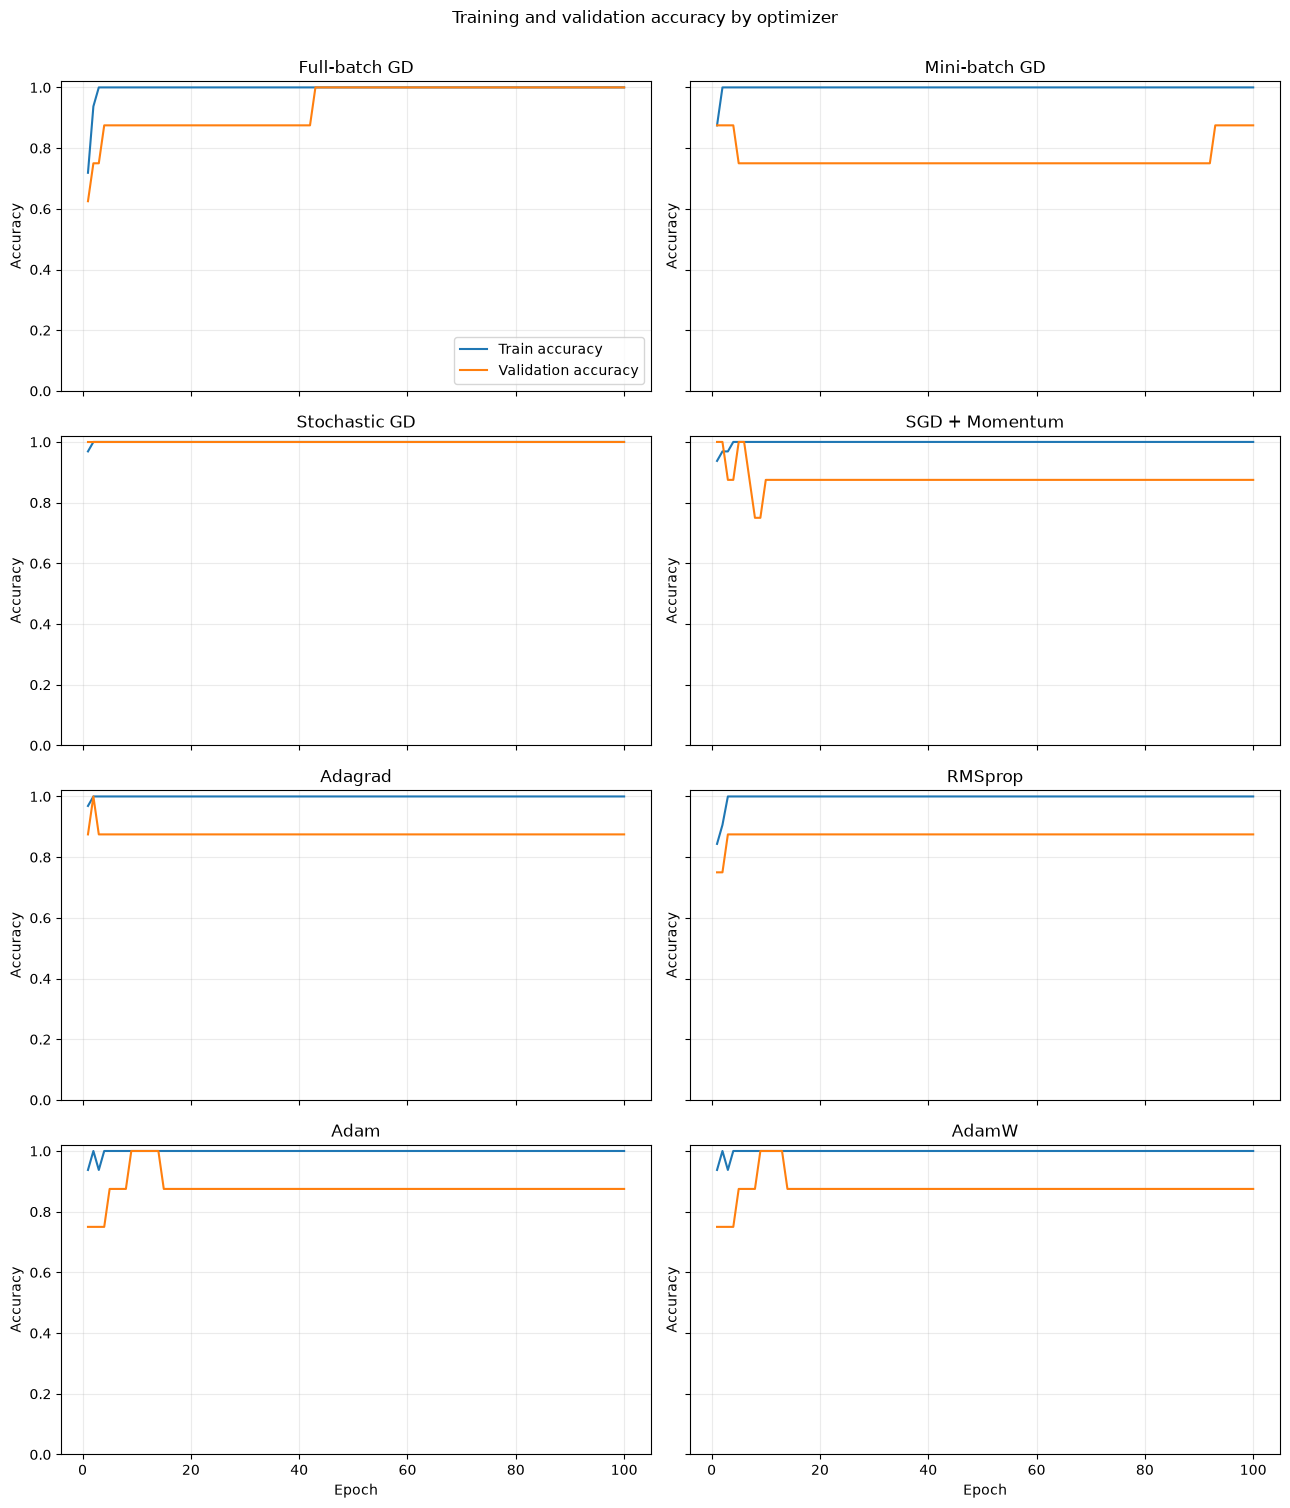

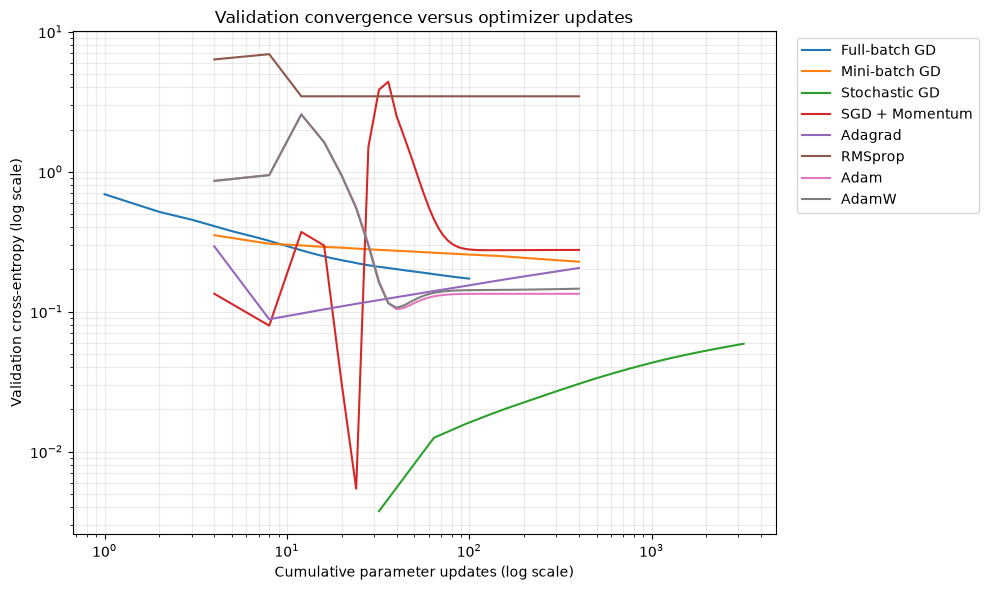

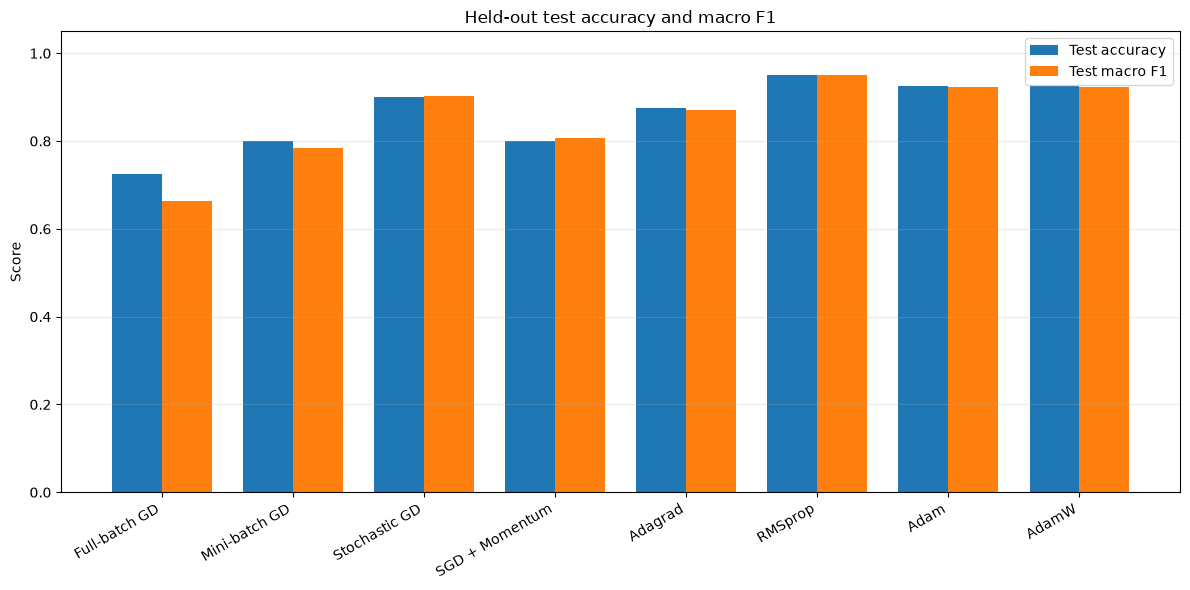

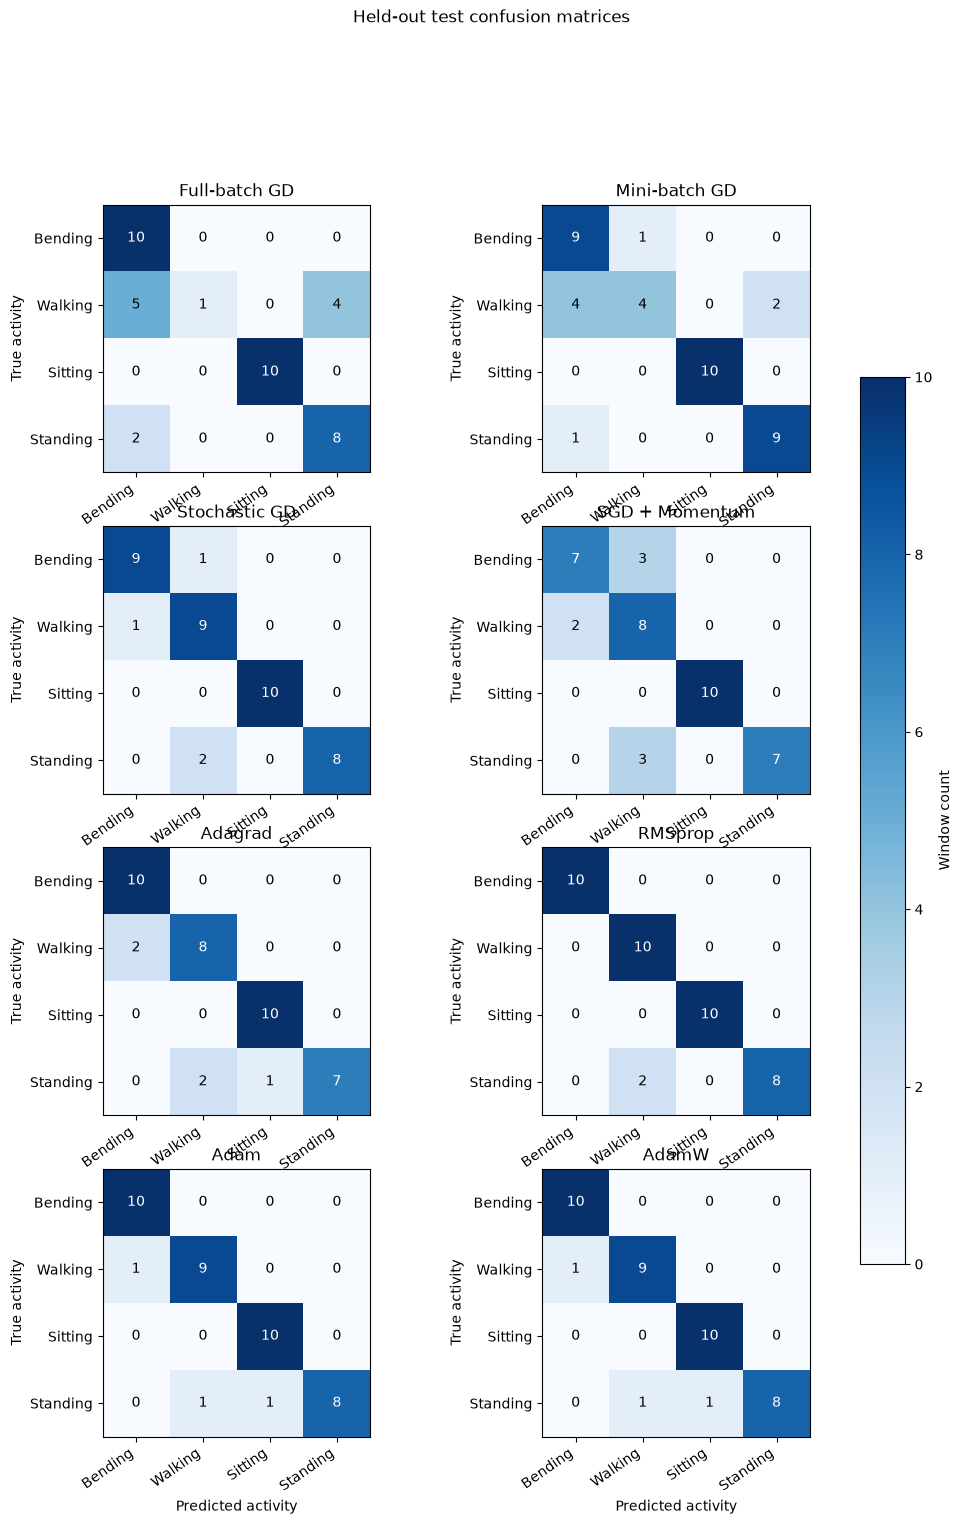

,optimizer,best_validation_loss,best_epoch,test_accuracy,test_macro_f1,training_seconds,total_updates,updates_per_epoch
0,Full-batch GD,0.1720,100,0.725,0.6625,0.539,100,1
1,Mini-batch GD,0.2271,100,0.800,0.7851,0.881,400,4
2,Stochastic GD,0.0037,1,0.900,0.9018,4.905,3200,32
3,SGD + Momentum,0.0054,6,0.800,0.8068,1.464,400,4
4,Adagrad,0.0881,2,0.875,0.8713,2.102,400,4
5,RMSprop,3.4539,3,0.950,0.9495,2.338,400,4
6,Adam,0.1039,10,0.925,0.9234,2.774,400,4
7,AdamW,0.1066,10,0.925,0.9234,2.938,400,4


Plots saved under: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\processed_dataset\optimizer_comparison_20261003_095659\figures


In [6]:
FIGURE_DIR = EXPERIMENT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
optimizer_names = [config['name'] for config in OPTIMIZER_CONFIGS]

# Training and validation loss: aligned small multiples keep all eight runs legible.
fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharex=True)
for axis, optimizer_name in zip(axes.flat, optimizer_names):
    history = experiment_histories[optimizer_name]
    axis.plot(history['epoch'], history['train_loss'], label='Train loss')
    axis.plot(history['epoch'], history['validation_loss'], label='Validation loss')
    axis.set_title(optimizer_name)
    axis.set_ylabel('Cross-entropy loss')
    axis.grid(alpha=0.25)
axes[-1, 0].set_xlabel('Epoch')
axes[-1, 1].set_xlabel('Epoch')
axes[0, 0].legend()
fig.suptitle('Training and validation loss by optimizer', y=1.002)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'loss_by_epoch.png', dpi=160, bbox_inches='tight')
plt.show()

# Training and validation accuracy using the same epoch range.
fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharex=True, sharey=True)
for axis, optimizer_name in zip(axes.flat, optimizer_names):
    history = experiment_histories[optimizer_name]
    axis.plot(history['epoch'], history['train_accuracy'], label='Train accuracy')
    axis.plot(history['epoch'], history['validation_accuracy'], label='Validation accuracy')
    axis.set_title(optimizer_name)
    axis.set_ylabel('Accuracy')
    axis.set_ylim(0, 1.02)
    axis.grid(alpha=0.25)
axes[-1, 0].set_xlabel('Epoch')
axes[-1, 1].set_xlabel('Epoch')
axes[0, 0].legend(loc='lower right')
fig.suptitle('Training and validation accuracy by optimizer', y=1.002)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'accuracy_by_epoch.png', dpi=160, bbox_inches='tight')
plt.show()

# Show convergence against cumulative updates as well as against epochs.
fig, axis = plt.subplots(figsize=(10, 6))
for optimizer_name in optimizer_names:
    history = experiment_histories[optimizer_name]
    axis.plot(history['cumulative_updates'], history['validation_loss'], label=optimizer_name)
axis.set_xscale('log')
axis.set_yscale('log')
axis.set_xlabel('Cumulative parameter updates (log scale)')
axis.set_ylabel('Validation cross-entropy (log scale)')
axis.set_title('Validation convergence versus optimizer updates')
axis.grid(alpha=0.25, which='both')
axis.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'validation_loss_by_updates.png', dpi=160, bbox_inches='tight')
plt.show()

# Held-out test metrics are evaluated at each optimizer's best-validation checkpoint.
ordered_results = experiment_results.set_index('optimizer').loc[optimizer_names].reset_index()
positions = np.arange(len(optimizer_names))
bar_width = 0.38
fig, axis = plt.subplots(figsize=(12, 6))
axis.bar(positions - bar_width / 2, ordered_results['test_accuracy'], bar_width, label='Test accuracy')
axis.bar(positions + bar_width / 2, ordered_results['test_macro_f1'], bar_width, label='Test macro F1')
axis.set_xticks(positions, optimizer_names, rotation=30, ha='right')
axis.set_ylim(0, 1.05)
axis.set_ylabel('Score')
axis.set_title('Held-out test accuracy and macro F1')
axis.legend()
axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'test_metrics_by_optimizer.png', dpi=160, bbox_inches='tight')
plt.show()

# One 4 x 4 confusion matrix for each optimizer, shown in aligned small multiples.
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
activity_labels = [class_names[int(class_id)] for class_id in CLASS_IDS]
for axis, optimizer_name in zip(axes.flat, optimizer_names):
    matrix = experiment_confusion[optimizer_name]
    image = axis.imshow(matrix, cmap='Blues')
    axis.set_title(optimizer_name)
    axis.set_xticks(range(len(activity_labels)), activity_labels, rotation=35, ha='right')
    axis.set_yticks(range(len(activity_labels)), activity_labels)
    axis.set_xlabel('Predicted activity')
    axis.set_ylabel('True activity')
    threshold = matrix.max() / 2 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(column, row, str(matrix[row, column]), ha='center', va='center',
                      color='white' if matrix[row, column] > threshold else 'black')
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.72, label='Window count')
fig.suptitle('Held-out test confusion matrices', y=1.002)
fig.savefig(FIGURE_DIR / 'test_confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

summary_columns = [
    'optimizer', 'best_validation_loss', 'best_epoch', 'test_accuracy',
    'test_macro_f1', 'training_seconds', 'total_updates', 'updates_per_epoch',
]
report_summary = ordered_results[summary_columns].copy()
report_summary['training_seconds'] = report_summary['training_seconds'].round(3)
report_summary[['best_validation_loss', 'test_accuracy', 'test_macro_f1']] = report_summary[
    ['best_validation_loss', 'test_accuracy', 'test_macro_f1']
].round(4)
report_summary.to_csv(EXPERIMENT_DIR / 'optimizer_summary.csv', index=False)
display(report_summary)
print(f'Plots saved under: {FIGURE_DIR.resolve()}')

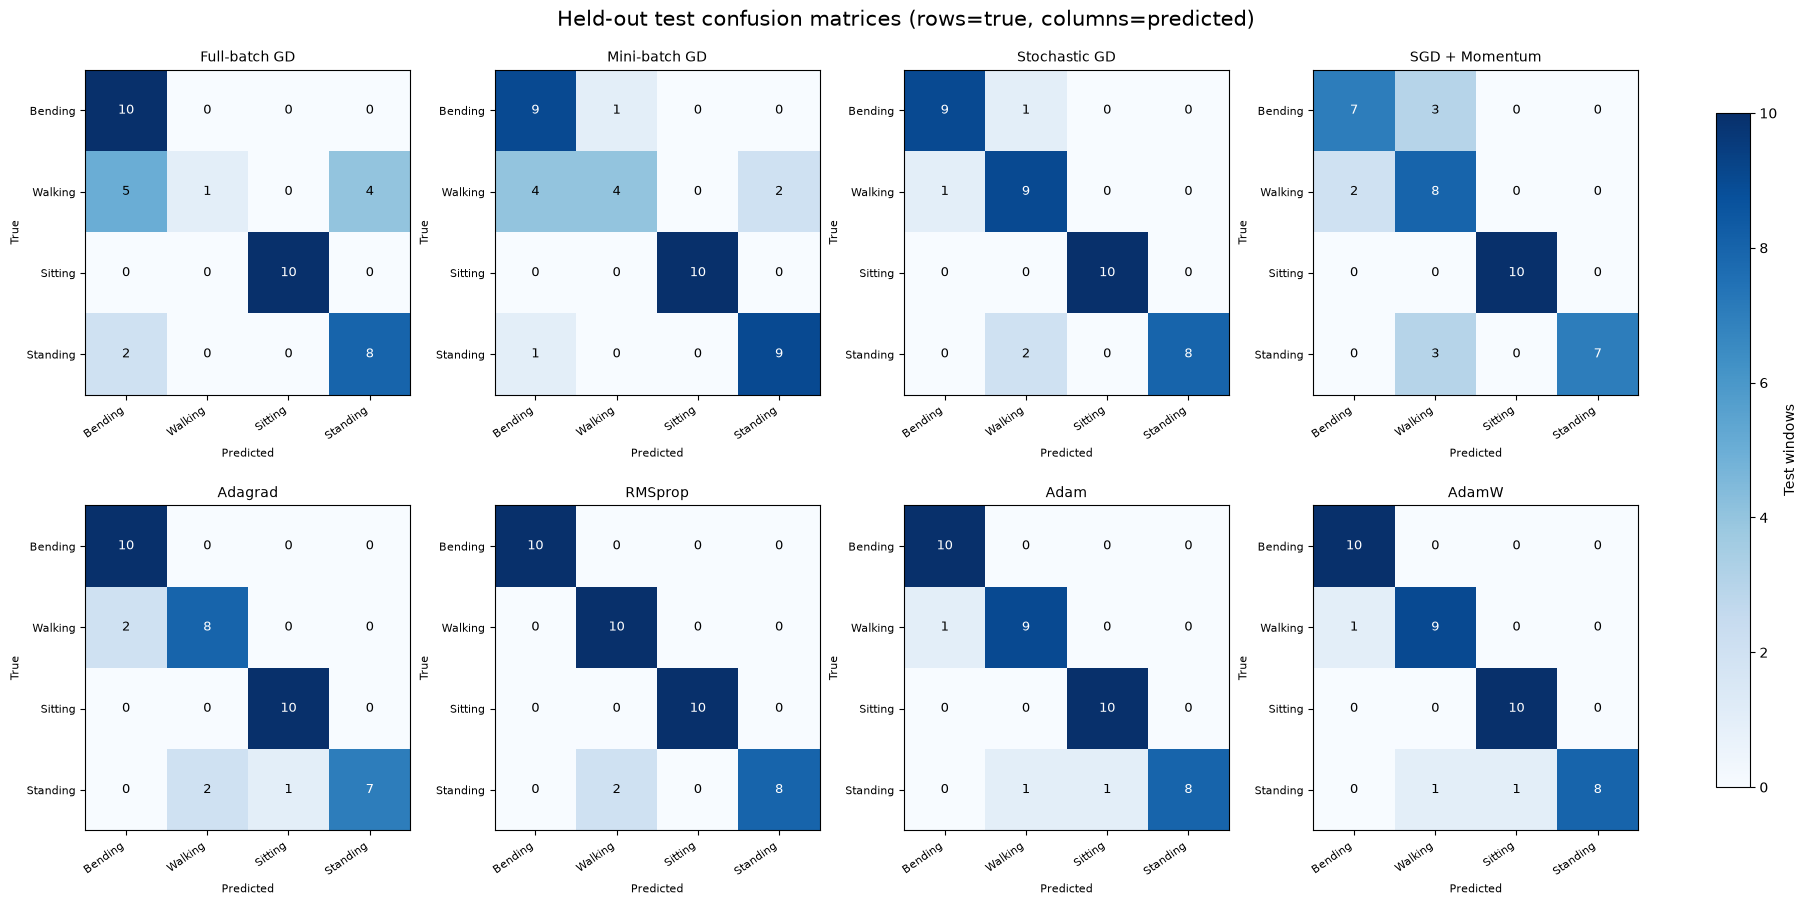

Saved report: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\processed_dataset\optimizer_comparison_20261003_095659\CogAge_optimizer_comparison_report.pdf
Saved report confusion matrices: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\processed_dataset\optimizer_comparison_20261003_095659\figures\test_confusion_matrices_report.png
Environment versions: {'python': '3.12.5', 'numpy': '2.5.3', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'scikit-learn': '1.9.1'}


In [7]:
import platform
import textwrap
from importlib.metadata import PackageNotFoundError, version
from matplotlib.backends.backend_pdf import PdfPages

# Save the second-stage scaler parameters and actual environment versions for reproducibility.
np.savez_compressed(
    EXPERIMENT_DIR / 'model_scaler.npz',
    mean=model_scaler.mean_,
    scale=model_scaler.scale_,
)
package_versions = {'python': platform.python_version()}
for package_name in ('numpy', 'pandas', 'matplotlib', 'scikit-learn'):
    try:
        package_versions[package_name] = version(package_name)
    except PackageNotFoundError:
        package_versions[package_name] = 'not installed'
(EXPERIMENT_DIR / 'environment_versions.json').write_text(
    json.dumps(package_versions, indent=2), encoding='utf-8'
)

# Make a less cramped 2 x 4 confusion-matrix figure for the report.
report_confusion_path = FIGURE_DIR / 'test_confusion_matrices_report.png'
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
for axis, optimizer_name in zip(axes.flat, optimizer_names):
    matrix = experiment_confusion[optimizer_name]
    image = axis.imshow(matrix, cmap='Blues', vmin=0, vmax=len(Y_heldout) // len(CLASS_IDS))
    axis.set_title(optimizer_name, fontsize=10)
    axis.set_xticks(range(len(activity_labels)), activity_labels, rotation=35, ha='right', fontsize=8)
    axis.set_yticks(range(len(activity_labels)), activity_labels, fontsize=8)
    axis.set_xlabel('Predicted', fontsize=8)
    axis.set_ylabel('True', fontsize=8)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(column, row, str(matrix[row, column]), ha='center', va='center', fontsize=9,
                      color='white' if matrix[row, column] > matrix.max() / 2 else 'black')
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82, label='Test windows')
fig.suptitle('Held-out test confusion matrices (rows=true, columns=predicted)', fontsize=15)
fig.savefig(report_confusion_path, dpi=220, bbox_inches='tight')
plt.show()


def add_text_page(pdf, title, sections):
    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.955, title, fontsize=18, weight='bold', va='top')
    current_y = 0.90
    for heading, paragraph in sections:
        page.text(0.08, current_y, heading, fontsize=12, weight='bold', va='top')
        current_y -= 0.035
        wrapped = textwrap.fill(paragraph, width=94)
        line_count = wrapped.count('\n') + 1
        page.text(0.08, current_y, wrapped, fontsize=9.5, va='top', linespacing=1.35)
        current_y -= line_count * 0.021 + 0.035
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)


def add_image_page(pdf, title, image_path, caption):
    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.96, title, fontsize=17, weight='bold', va='top')
    axis = page.add_axes([0.05, 0.13, 0.90, 0.78])
    axis.imshow(plt.imread(image_path))
    axis.set_aspect('auto')
    axis.axis('off')
    page.text(0.07, 0.075, textwrap.fill(caption, width=105), fontsize=9, va='bottom')
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)


optimizer_table_rows = [
    [config['name'], str(len(X_fit) if config['batch_size'] is None else config['batch_size']),
     str(int(np.ceil(len(X_fit) / (len(X_fit) if config['batch_size'] is None else config['batch_size']))))]
    for config in OPTIMIZER_CONFIGS
]

report_path = EXPERIMENT_DIR / 'CogAge_optimizer_comparison_report.pdf'
with PdfPages(report_path) as pdf:
    add_text_page(pdf, 'CogAge Atomic Behaviour: optimizer comparison', [
        ('Objective', 'Compare eight update configurations for four-class activity classification using a fixed fully connected network. The held-out test set is not used to choose epochs or optimizer settings.'),
        ('Selected classes and labels', 'Bending=0, Walking=1, Sitting=2, Standing=3. The four labels come from the activity token in the folder name, not from a label column in the raw sensor files.'),
        ('Original split and window counts', 'For every selected class, _1_extracted is the training recording and _2_extracted is the test recording. The raw recordings provide 10 Events per split and class. Windowing yields 10 complete windows per class in original train and 10 per class in held-out test. From original training only, 2 Events per class (8 windows total) are assigned to validation; 8 per class (32 total) remain for model fitting. Test remains 40 windows.'),
        ('Input preparation', 'Semicolon-delimited sensor files use epoch-millisecond timestamps. The selected folders contain 12 sensor types with differing measurement widths and sampling intervals. Streams are averaged onto a 20 ms grid, linearly interpolated, synchronized within each Event, and divided into non-overlapping 128-step windows. Each window has 33 features. Raw audit: 960 files, zero malformed rows and zero missing raw measurement values. Resampling introduced sparse-grid NaNs that were interpolated; incomplete event tails were discarded.'),
        ('Validation and limitations', 'The validation split groups windows by original folder and Event and is seeded. All recordings are from Subject 1, so this cannot measure generalization to unseen participants. The final model-training set contains only 32 windows, which is very small relative to the network capacity.'),
    ])

    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.955, 'Network and experimental configurations', fontsize=17, weight='bold', va='top')
    page.text(0.08, 0.90, f'Input: 128 x 33 flattened to {INPUT_DIM}; architecture: {INPUT_DIM} -> {HIDDEN_DIMS[0]} -> {HIDDEN_DIMS[1]} -> 4 logits; ReLU hidden activations; {PARAMETER_COUNT:,} trainable parameters.', fontsize=9.5, va='top', wrap=True)
    page.text(0.08, 0.84, 'Weights use the same He-normal initialization seed (42) in each run. Loss is sparse categorical cross-entropy from logits, computed with numerically stable softmax. No softmax is added to the model output.', fontsize=9.5, va='top', wrap=True)
    table_axis = page.add_axes([0.07, 0.47, 0.86, 0.31])
    table_axis.axis('off')
    config_table = table_axis.table(
        cellText=optimizer_table_rows,
        colLabels=['Configuration', 'Batch size', 'Updates / epoch'],
        colLoc='left', cellLoc='left', loc='center',
        colWidths=[0.48, 0.20, 0.26],
    )
    config_table.auto_set_font_size(False)
    config_table.set_fontsize(8.5)
    config_table.scale(1, 1.45)
    page.text(0.08, 0.42, 'Fixed settings', fontsize=11, weight='bold', va='top')
    fixed_settings = (
        f'{MAX_EPOCHS} epochs; learning rate {BASE_LEARNING_RATE} for every method; mini-batch size {MINI_BATCH_SIZE}; '
        f'momentum {MOMENTUM_COEFFICIENT}; RMSprop decay 0.99; Adam/AdamW betas (0.9, 0.999); '
        f'AdamW decoupled weight decay {ADAMW_WEIGHT_DECAY}. All experiments use the same data, initialization, '
        'loss, and maximum epochs. Plain NumPy optimizer updates are implemented directly.'
    )
    page.text(0.08, 0.38, textwrap.fill(fixed_settings, width=95), fontsize=9, va='top', linespacing=1.35)
    page.text(0.08, 0.22, 'Runtime measures training plus per-epoch train/validation scoring; the one-time held-out test evaluation is excluded. Epochs are not directly comparable as update counts differ substantially.', fontsize=9, va='top', wrap=True)
    page.text(0.08, 0.13, 'Reproducibility: seeds 42/43 for model initialization and batch ordering. Run the preprocessing script, then execute this notebook top to bottom. Each experiment writes to a fresh timestamped subfolder.', fontsize=9, va='top', wrap=True)
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)

    add_image_page(
        pdf, 'Training and validation loss', FIGURE_DIR / 'loss_by_epoch.png',
        'Figure 1. Cross-entropy loss by epoch for all eight optimizers. Each panel uses its own y scale so method-specific changes remain visible. Checkpoints are selected using validation loss only.'
    )
    add_image_page(
        pdf, 'Training and validation accuracy', FIGURE_DIR / 'accuracy_by_epoch.png',
        'Figure 2. Training and validation accuracy by epoch. Validation contains only eight windows (two per class), so each error changes validation accuracy by 12.5 percentage points.'
    )

    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.96, 'Convergence and held-out test metrics', fontsize=17, weight='bold', va='top')
    update_axis = page.add_axes([0.08, 0.55, 0.84, 0.32])
    update_axis.imshow(plt.imread(FIGURE_DIR / 'validation_loss_by_updates.png'))
    update_axis.set_aspect('auto')
    update_axis.axis('off')
    page.text(0.08, 0.50, 'Figure 3. Validation loss versus cumulative parameter updates (both axes logarithmic). Full-batch GD makes one update per epoch; mini-batch configurations make four; stochastic GD makes 32.', fontsize=8.5, va='top', wrap=True)
    metric_axis = page.add_axes([0.08, 0.12, 0.84, 0.31])
    metric_axis.imshow(plt.imread(FIGURE_DIR / 'test_metrics_by_optimizer.png'))
    metric_axis.set_aspect('auto')
    metric_axis.axis('off')
    page.text(0.08, 0.075, 'Figure 4. Test accuracy and macro F1 for the checkpoint chosen by validation loss. Test data is evaluated once per run and is not used for model selection.', fontsize=8.5, va='top', wrap=True)
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)

    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.96, 'Test results, confusion matrices, and interpretation', fontsize=16, weight='bold', va='top')
    matrix_axis = page.add_axes([0.05, 0.56, 0.90, 0.34])
    matrix_axis.imshow(plt.imread(report_confusion_path))
    matrix_axis.set_aspect('auto')
    matrix_axis.axis('off')
    page.text(0.07, 0.54, 'Figure 5. Per-optimizer 4 x 4 confusion matrices. Rows are true classes; columns are predicted classes.', fontsize=8.5, va='top')

    result_rows = []
    for _, result in ordered_results.iterrows():
        result_rows.append([
            result['optimizer'], f"{result['best_validation_loss']:.3f}", int(result['best_epoch']),
            f"{result['test_accuracy']:.3f}", f"{result['test_macro_f1']:.3f}",
            f"{result['training_seconds']:.2f}", f"{int(result['total_updates']):,}",
        ])
    results_axis = page.add_axes([0.06, 0.30, 0.88, 0.20])
    results_axis.axis('off')
    results_table = results_axis.table(
        cellText=result_rows,
        colLabels=['Optimizer', 'Best val loss', 'Epoch', 'Test acc.', 'Macro F1', 'Seconds', 'Updates'],
        colLoc='center', cellLoc='center', loc='center',
        colWidths=[0.20, 0.14, 0.08, 0.12, 0.12, 0.12, 0.14],
    )
    results_table.auto_set_font_size(False)
    results_table.set_fontsize(7.2)
    results_table.scale(1, 1.38)

    top_test = ordered_results.sort_values('test_accuracy', ascending=False).iloc[0]
    interpretation = (
        f"In this run, {top_test['optimizer']} had the highest test accuracy "
        f"({top_test['test_accuracy']:.1%}; macro F1 {top_test['test_macro_f1']:.3f}). "
        'RMSprop also had a high test score but a very poor best validation loss, showing the instability of selecting on only eight validation examples. '
        'Stochastic GD reached strong validation/test scores but required 3,200 updates and the longest measured time. Full-batch GD used the fewest updates and least time, but its test score was lower. Adam and AdamW were nearly identical here; this small run does not establish a general optimizer ranking.'
    )
    page.text(0.07, 0.26, textwrap.fill(interpretation, width=112), fontsize=8.1, va='top', linespacing=1.25)
    page.text(0.07, 0.115, textwrap.fill(
        'Limitations: one subject, only 32 model-training and 8 validation windows, and 135,796 parameters. The validation estimates are noisy, and results are not participant-independent. No class balancing was needed because each class had equal window counts. Do not interpret the held-out test results as evidence of broad population generalization.',
        width=112), fontsize=8, va='top', linespacing=1.25)
    page.text(0.07, 0.035, 'AI assistance disclosure: GitHub Copilot assisted with drafting and debugging code. The student should verify the experiment and include this disclosure as required by course policy.', fontsize=7.5, va='bottom')
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)

print('Saved report:', report_path.resolve())
print('Saved report confusion matrices:', report_confusion_path.resolve())
print('Environment versions:', package_versions)